In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import csv

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv(
    'TASK3 data.csv',
    sep=';',
    quoting=csv.QUOTE_NONE,
    engine='python'
)

In [3]:
df.head()

,"""age","""""job""""","""""marital""""","""""education""""","""""default""""","""""balance""""","""""housing""""","""""loan""""","""""contact""""","""""day""""","""""month""""","""""duration""""","""""campaign""""","""""pdays""""","""""previous""""","""""poutcome""""","""""y"""""""
0,"""30","""""unemployed""""","""""married""""","""""primary""""","""""no""""",1787,"""""no""""","""""no""""","""""cellular""""",19,"""""oct""""",79,1,-1,0,"""""unknown""""","""""no"""""""
1,"""33","""""services""""","""""married""""","""""secondary""""","""""no""""",4789,"""""yes""""","""""yes""""","""""cellular""""",11,"""""may""""",220,1,339,4,"""""failure""""","""""no"""""""
2,"""35","""""management""""","""""single""""","""""tertiary""""","""""no""""",1350,"""""yes""""","""""no""""","""""cellular""""",16,"""""apr""""",185,1,330,1,"""""failure""""","""""no"""""""
3,"""30","""""management""""","""""married""""","""""tertiary""""","""""no""""",1476,"""""yes""""","""""yes""""","""""unknown""""",3,"""""jun""""",199,4,-1,0,"""""unknown""""","""""no"""""""
4,"""59","""""blue-collar""""","""""married""""","""""secondary""""","""""no""""",0,"""""yes""""","""""no""""","""""unknown""""",5,"""""may""""",226,1,-1,0,"""""unknown""""","""""no"""""""


In [4]:
# Remove extra quotes
df.columns = df.columns.str.replace('"', '', regex=False)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('"', '', regex=False)

In [5]:
df.shape

(4521, 17)

In [6]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   object
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(6), object(11)
memory usage: 600.6+ KB


In [10]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

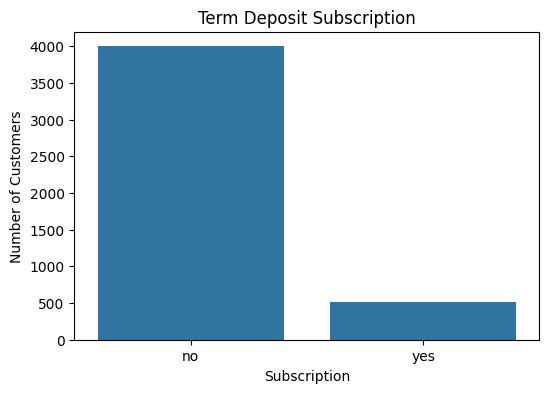

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='y')

plt.title('Term Deposit Subscription')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')

plt.show()

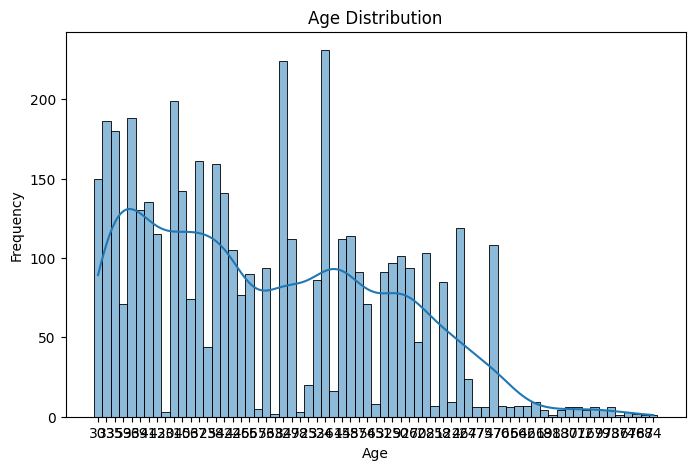

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

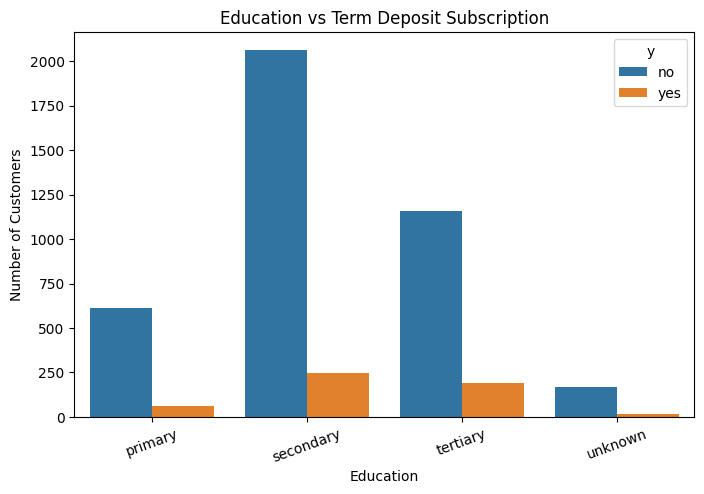

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='education',
    hue='y'
)

plt.title('Education vs Term Deposit Subscription')
plt.xlabel('Education')
plt.ylabel('Number of Customers')

plt.xticks(rotation=20)

plt.show()

In [14]:
print(df['y'].unique())
print(df['y'].value_counts(dropna=False))

['no' 'yes']
y
no     4000
yes     521
Name: count, dtype: int64


In [15]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [19]:
numric_features = df.select_dtypes(include=['int64', 'float64']).columns
numeric_features = numric_features
categorical_features = df.select_dtypes(include=['object']).columns

print("numerical", numric_features.to_list())
print("categorical", categorical_features.to_list())
categorical_features=df.select_dtypes(include=['object']).columns
print("numerical",numric_features.to_list())
print("categorical",categorical_features.to_list())

numerical ['balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
numerical ['balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [20]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [21]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, categorical_features),
        ('num', numeric_pipeline, numric_features)
    ]
)
preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [23]:
# Normalize target labels before encoding
df['y'] = (
    df['y']
    .astype('string')
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.lower()
)

print("Original target values:", df['y'].unique())

df['y'] = df['y'].map({
    'yes': 1,
    'no': 0,
    '1': 1,
    '0': 0
})

if df['y'].isna().any():
    raise ValueError(f"Unrecognized target values: {df['y'].unique()}")

x = df.drop(columns='y')
y = df['y']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=42, stratify=y, test_size=0.2
)

Original target values: <StringArray>
['no', 'yes']
Length: 2, dtype: string


In [25]:
model_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))

])

# Rebuild the preprocessor using ONLY feature columns (exclude target 'y')
categorical_features = x.columns[x.dtypes == object]
numeric_features = x.columns[x.dtypes != object]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, categorical_features),
        ('num', numeric_pipeline, numeric_features)
    ]
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

model_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred=model_pipeline.predict(x_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("accuracy",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuracy 0.8740331491712707
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       801
           1       0.47      0.69      0.56       104

    accuracy                           0.87       905
   macro avg       0.71      0.79      0.74       905
weighted avg       0.90      0.87      0.88       905



In [28]:
from sklearn.metrics import confusion_matrix

confusion_matrix_result = confusion_matrix(y_test, y_pred)
print(confusion_matrix_result)

[[719  82]
 [ 32  72]]


In [29]:
import joblib

joblib.dump(model_pipeline, "random_forest_model.pkl")

['random_forest_model.pkl']

In [30]:
joblib.dump(x_test, "x_test.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']